## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [3]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Using all orb-weavers

98 species total, 44 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.49, Stddev: 1.55, Count of HOGs: 9490
Log odds ratios of DUPLICATION: 
 Mean: 0.08, Stddev: 1.14, Count of HOGs: 12096

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 95 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [07:30<00:00, 22.19it/s]


Permulation counter for MEANS:
 Loss: 2075, Duplication: 2229
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 95
Analysis run on 2026-04-13 at 15:07:39
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 9490 (loss), 12096 (duplication)
Total species: 98
Foreground count: 44
Background count: 54
True mean, loss: -0.486
True standard deviation, loss: 1.547
True mean, duplication: 0.079
True standard deviation, duplication: 1.136

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.207
Probability that the null is true for MEAN, duplication (alt=greater): 0.223

Permulated average mean, loss: -0.006
Permulated average s

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list.txt, background_list_filename=None), min_occ=30, permulation_reps=10000)

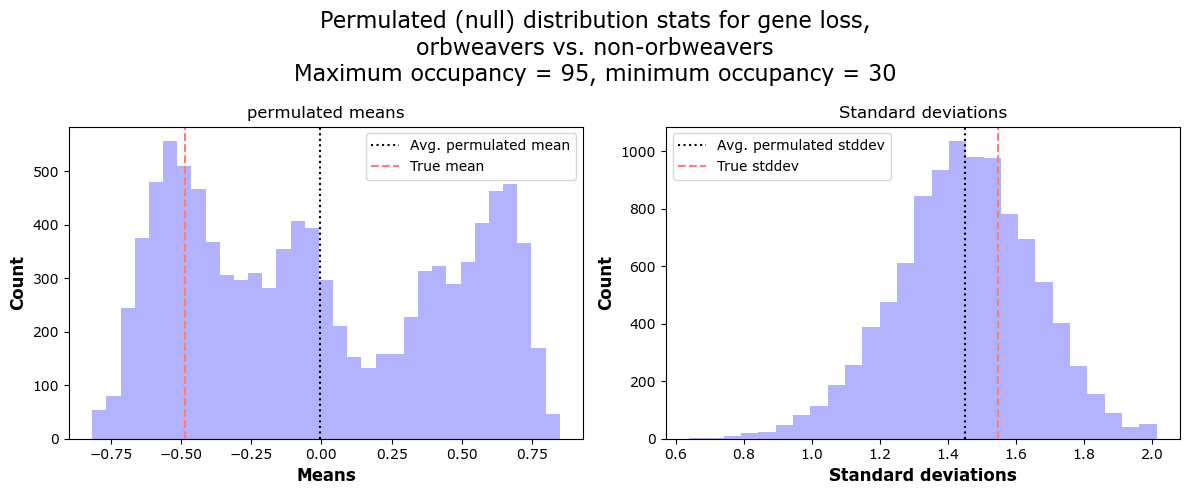

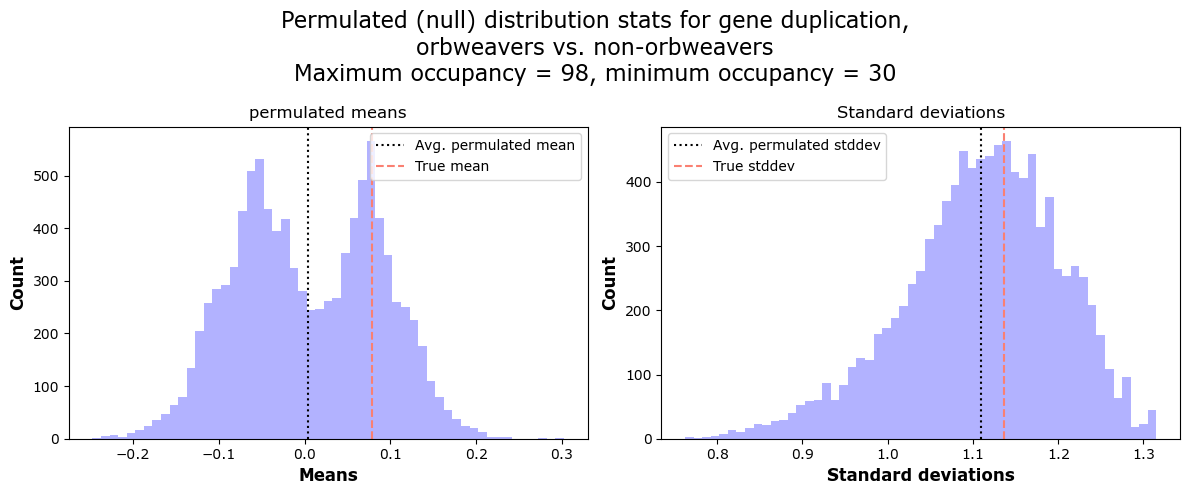

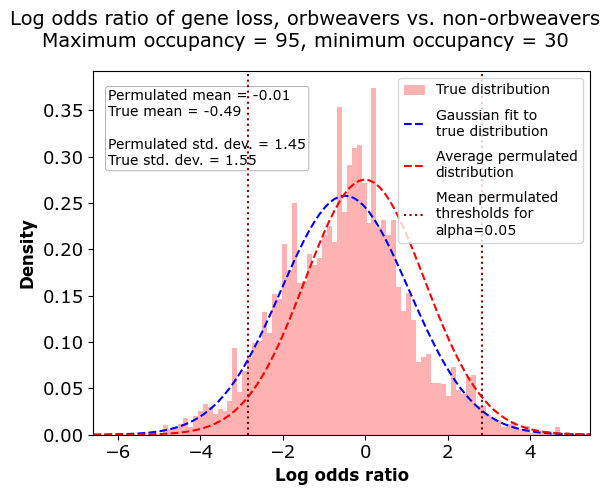

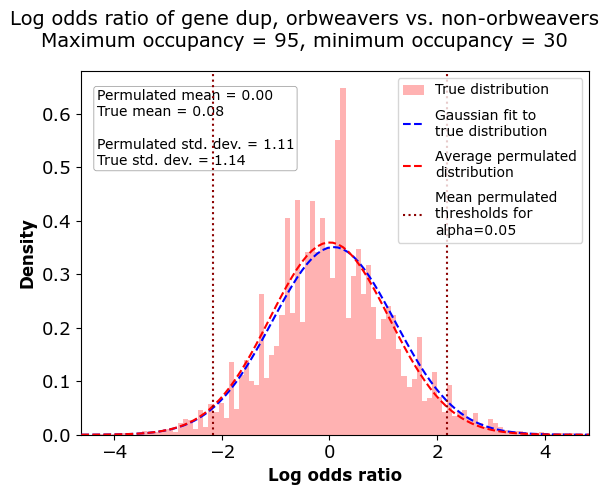

In [4]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=95,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

## Without Araneids

68 species total, 17 foreground, 51 background
Log odds ratios of LOSS: 
 Mean: -0.30, Stddev: 1.61, Count of HOGs: 5973
Log odds ratios of DUPLICATION: 
 Mean: 0.23, Stddev: 1.11, Count of HOGs: 8837

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 65 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [06:43<00:00, 24.76it/s]


Permulation counter for MEANS:
 Loss: 4521, Duplication: 962
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 65
Analysis run on 2026-04-13 at 15:19:12
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list-no-araneids.txt
Background list: /Users/calvin/orb-selection/data/non-orb-weavers-no-araneids.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5973 (loss), 8837 (duplication)
Total species: 68
Foreground count: 17
Background count: 51
True mean, loss: -0.299
True standard deviation, loss: 1.606
True mean, duplication: 0.232
True standard deviation, duplication: 1.108

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.452
Probability that the null is true for MEAN, 

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list-no-araneids.txt, background_list_filename=/Users/calvin/orb-selection/data/non-orb-weavers-no-araneids.txt), min_occ=30, permulation_reps=10000)

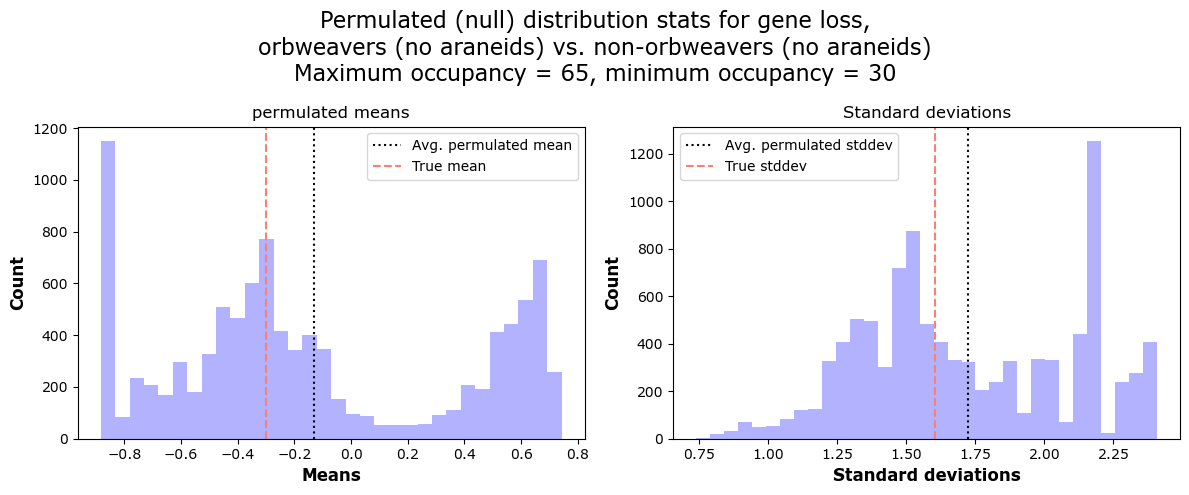

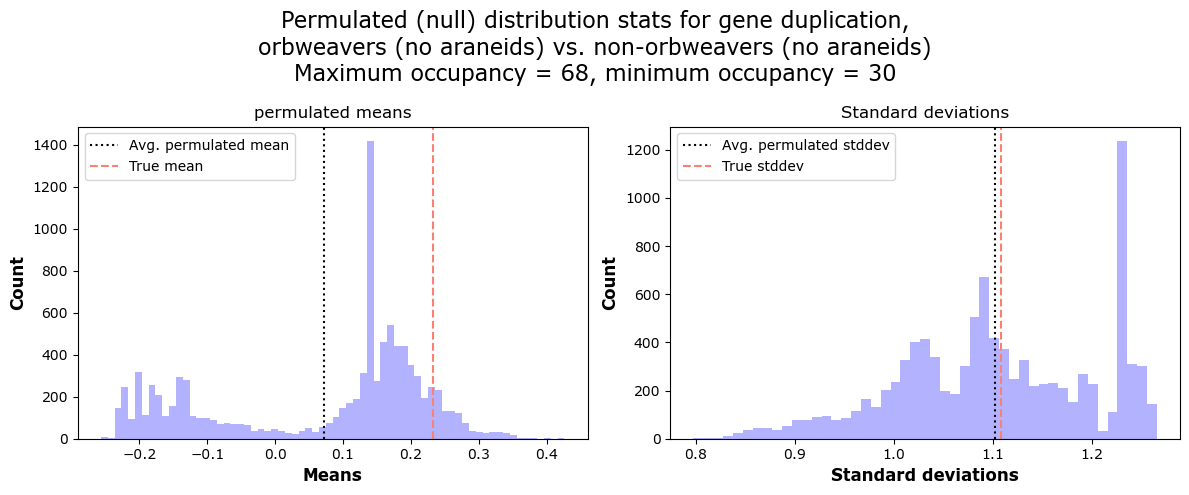

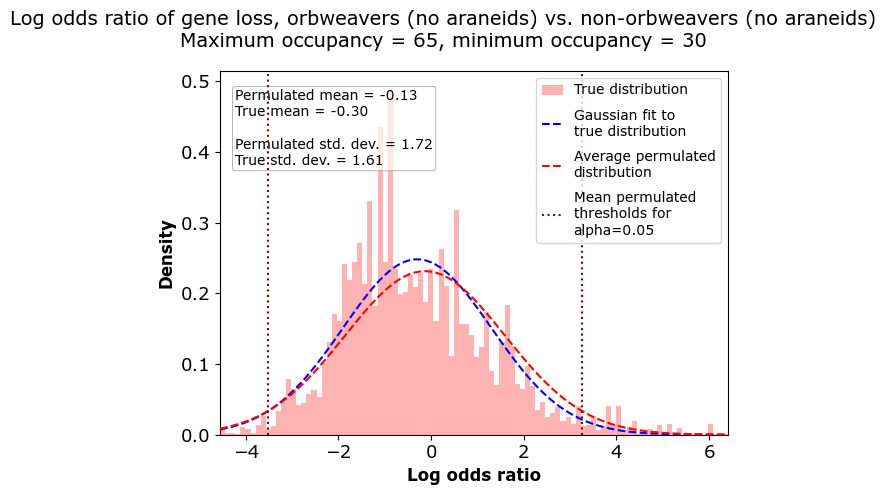

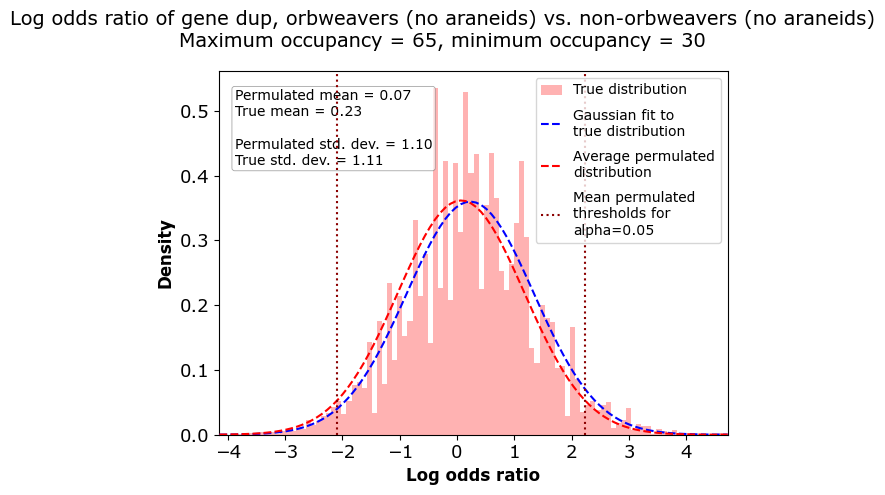

In [7]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=65,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no araneids)',
    bg_name='non-orbweavers (no araneids)',
    foreground_list_filename="data/orbweavers-list-no-araneids.txt",
    background_list_filename="data/non-orb-weavers-no-araneids.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_araneids.csv",
)

## Without Tetragnathids

84 species total, 30 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.67, Stddev: 1.82, Count of HOGs: 8108
Log odds ratios of DUPLICATION: 
 Mean: 0.05, Stddev: 1.25, Count of HOGs: 10878

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 81 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [06:51<00:00, 24.32it/s]


Permulation counter for MEANS:
 Loss: 4463, Duplication: 3810
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 81
Analysis run on 2026-04-13 at 15:26:43
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list-no-tetragnathids.txt
Background list: /Users/calvin/orb-selection/data/non-orb-weavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 8108 (loss), 10878 (duplication)
Total species: 84
Foreground count: 30
Background count: 54
True mean, loss: -0.674
True standard deviation, loss: 1.817
True mean, duplication: 0.050
True standard deviation, duplication: 1.252

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.446
Probability that the null is true for MEAN, 

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list-no-tetragnathids.txt, background_list_filename=/Users/calvin/orb-selection/data/non-orb-weavers-list.txt), min_occ=30, permulation_reps=10000)

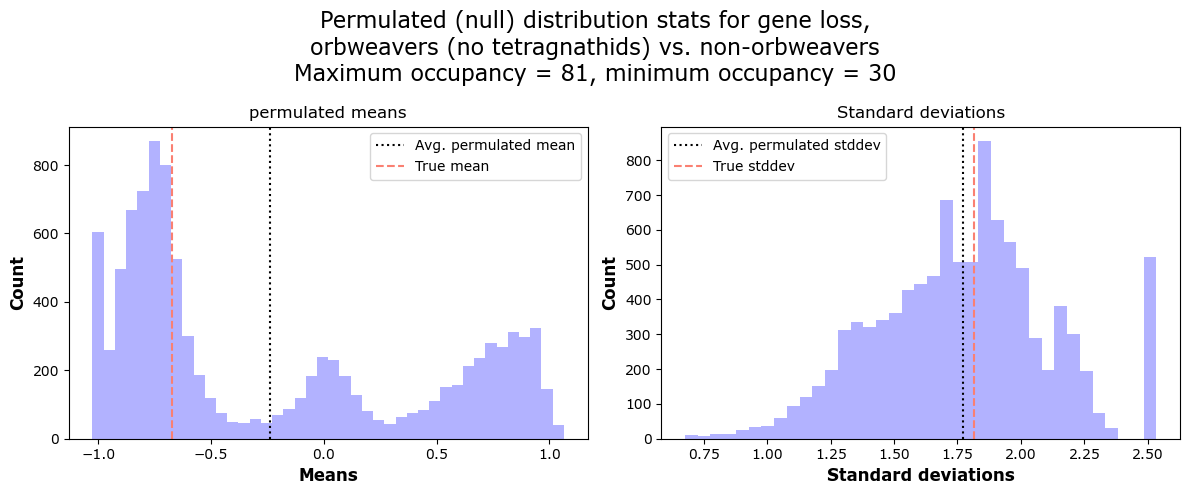

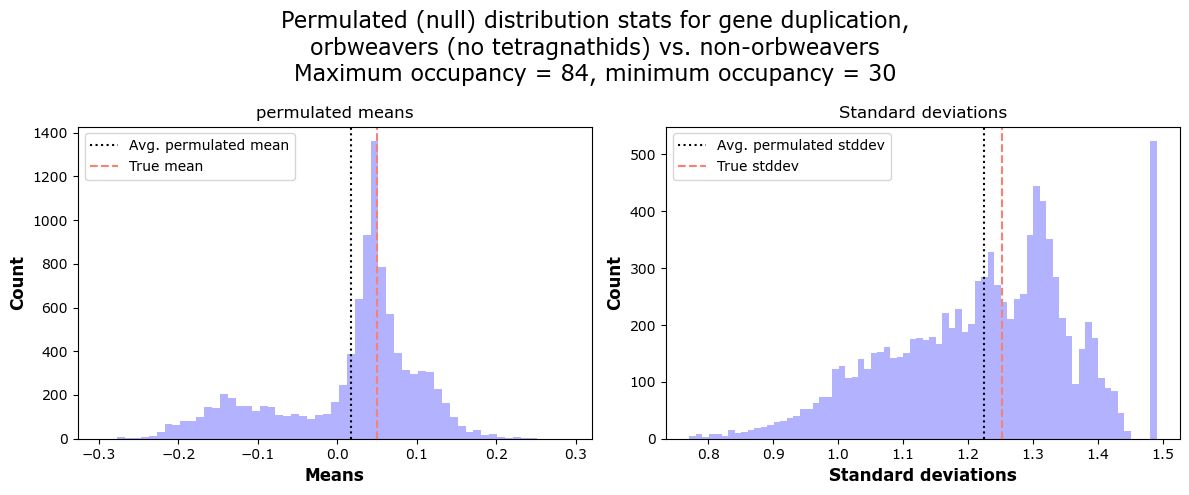

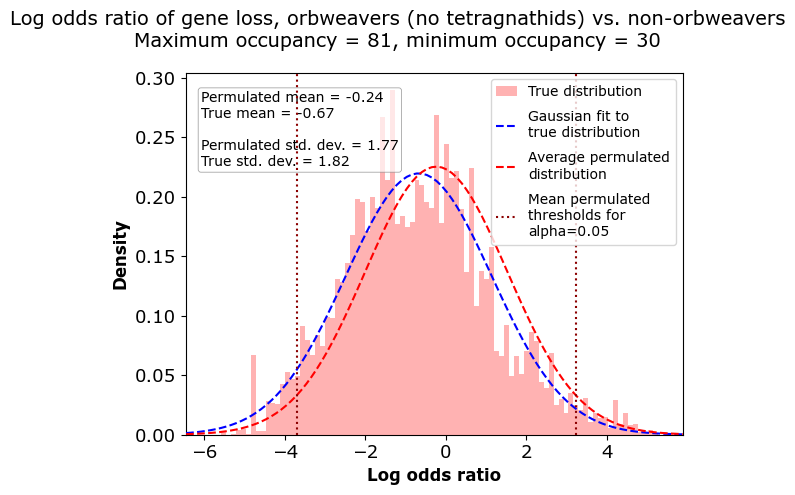

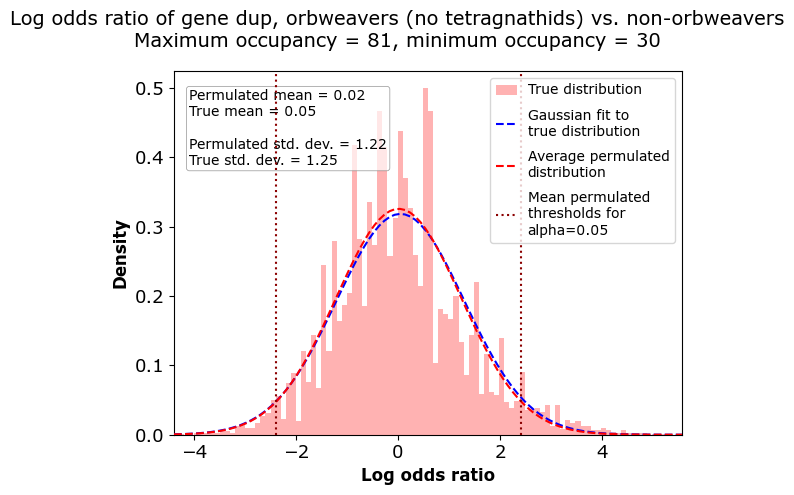

In [8]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=81,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-tetragnathids.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_tetragnathids.csv",
)

In [34]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr13/Run1_occ_30-95_10000x/results.pkl"
)
run1_df = results_all.results_fltrd_df_all
run1_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0002072,52,3.473733,-0.762726,0.0108,0.9892,0.7989,0.2011,True
N5.HOG0004196,36,2.897408,-1.849984,0.0821,0.9179,0.8589,0.1409,False
N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True
N5.HOG0008044,34,3.217038,-2.610164,0.0729,0.9271,0.9248,0.0751,False
N5.HOG0010012,32,3.032434,-1.496226,0.1139,0.8861,0.8669,0.1331,False
...,...,...,...,...,...,...,...,...
N5.HOG0071055,40,1.429047,-3.137139,0.0756,0.9244,0.9392,0.0608,False
N5.HOG0071758,38,3.059209,-2.803894,0.0921,0.9079,0.9553,0.0446,True
N5.HOG0071935,43,2.825955,-2.566498,0.1280,0.8720,0.9165,0.0833,False


In [35]:
%autoreload 2
results_no_ara = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr13/Run2_occ_30-65_10000x/results.pkl"
)
run2_df = results_no_ara.results_fltrd_df_all
run2_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0002072,48,3.353081,0.124412,0.0321,0.9583,0.3474,0.6430,True
N5.HOG0005532,57,3.842638,0.668708,0.0246,0.9657,0.0432,0.9472,True
N5.HOG0007439,30,3.853975,-2.616713,0.0078,0.9825,0.8505,0.1399,True
N5.HOG0007845,49,4.196621,-2.796581,0.0029,0.9875,0.9210,0.0694,True
N5.HOG0010634,55,4.331416,-0.912238,0.1166,0.8733,0.7661,0.2243,False
...,...,...,...,...,...,...,...,...
N5.HOG0068730,42,3.089506,-2.436155,0.0116,0.9788,0.8918,0.0986,False
N5.HOG0069974,39,-1.051603,-2.529815,0.4916,0.4988,0.6416,0.3488,False
N5.HOG0070676,30,2.023407,-2.700745,0.1048,0.8855,0.7643,0.2261,False


In [36]:
%autoreload 2
results_no_tet = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr13/Run3_occ_30-81_10000x/results.pkl"
)
run3_df = results_no_tet.results_fltrd_df_all
run3_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0001041,40,3.263230,-0.857170,0.0003,0.9997,0.7979,0.2020,True
N5.HOG0002072,50,3.453174,-0.391856,0.0867,0.9133,0.7978,0.2021,False
N5.HOG0004196,34,3.356732,-1.479114,0.2914,0.7086,0.8021,0.1978,False
N5.HOG0007439,30,4.267289,-3.107778,0.0165,0.9835,0.8615,0.1385,True
N5.HOG0007639,50,3.908429,-1.396016,0.3286,0.6714,0.7307,0.2693,False
...,...,...,...,...,...,...,...,...
N5.HOG0071484,30,0.849227,-2.643093,0.1004,0.8996,0.8592,0.1406,False
N5.HOG0071758,38,2.643444,-2.433024,0.4124,0.5876,0.8362,0.1636,False
N5.HOG0071948,33,1.338423,-2.548809,0.3843,0.6157,0.8556,0.1444,False


In [42]:
run1_df_fltrd = run1_df[
    run1_df["Significant in permulation test"]
]
run2_df_fltrd = run2_df[
    run2_df["Significant in permulation test"]
]
run3_df_fltrd = run3_df[
    run3_df["Significant in permulation test"]
]

common_hogs = run1_df_fltrd.index.intersection(run2_df_fltrd.index).intersection(run3_df_fltrd.index)
intersection_df = run1_df_fltrd.loc[common_hogs]
intersection_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True
N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True
N5.HOG0022325,34,3.812024,-3.426032,0.0075,0.9925,0.9656,0.0343,True
N5.HOG0033305,33,4.870321,-3.217480,0.0076,0.9924,0.9439,0.0559,True
N5.HOG0036007,31,4.719117,-1.588599,0.0065,0.9935,0.8698,0.1301,True
N5.HOG0043760,35,5.023451,-3.020487,0.0046,0.9954,0.9393,0.0603,True
N5.HOG0043831,30,4.644039,-1.832478,0.0113,0.9887,0.8984,0.1016,True
N5.HOG0047981,33,4.863396,-3.558733,0.0044,0.9956,0.9581,0.0418,True
N5.HOG0048549,61,4.353531,-1.561977,0.0001,0.9999,0.9176,0.0824,True


Of interest: innexin, slit, osteopetrosis-associated transmembrane protein (nervous), pantetheinase (oxidative stress)

Makes sense that the ones that are more likely lost in orb-weavers and more likely duplicated in non-orb-weavers are unannotated in U.div! Maybe I should annotate them using a non-orb-weaver genome

In [43]:
convert_hogs_to_locs(intersection_df, results_all.true_odds.hog_node_genes_tsv)

Processing HOGs: 100%|██████████| 26/26 [00:00<00:00, 1488.19it/s]


,HOG,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test,udiv_genes,dmel_orthologs,LOC,txpt,GO_terms,Description
0,N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True,,,NaN,NaN,NaN,NaN
1,N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True,,,NaN,NaN,NaN,NaN
2,N5.HOG0022325,34,3.812024,-3.426032,0.0075,0.9925,0.9656,0.0343,True,,,NaN,NaN,NaN,NaN
3,N5.HOG0033305,33,4.870321,-3.217480,0.0076,0.9924,0.9439,0.0559,True,,,NaN,NaN,NaN,NaN
4,N5.HOG0036007,31,4.719117,-1.588599,0.0065,0.9935,0.8698,0.1301,True,,,NaN,NaN,NaN,NaN
5,N5.HOG0043760,35,5.023451,-3.020487,0.0046,0.9954,0.9393,0.0603,True,,,NaN,NaN,NaN,NaN
6,N5.HOG0043831,30,4.644039,-1.832478,0.0113,0.9887,0.8984,0.1016,True,,,NaN,NaN,NaN,NaN
7,N5.HOG0047981,33,4.863396,-3.558733,0.0044,0.9956,0.9581,0.0418,True,,,NaN,NaN,NaN,NaN
8,N5.HOG0048549,61,4.353531,-1.561977,0.0001,0.9999,0.9176,0.0824,True,,,NaN,NaN,NaN,NaN
9,N5.HOG0054184,31,4.717420,-4.019122,0.0088,0.9912,0.9551,0.0445,True,,,NaN,NaN,NaN,NaN
